# TrainWise AI

## Cloud Cost Intelligence Platform for Large-Scale AI Training Workloads

### Problem Statement

Training modern AI models requires significant cloud compute resources, making cost estimation a critical challenge for organizations.

This project aims to forecast AI training costs based on workload characteristics such as GPU usage, model size, dataset size, storage requirements, and inference workloads.

### Objectives

- Perform Exploratory Data Analysis (EDA)
- Engineer meaningful features
- Build Linear Regression models
- Compare Ridge, Lasso and ElasticNet
- Evaluate model performance
- Deploy an interactive forecasting platform

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

# Dataset Design

## Business Context

TrainWise AI is designed to forecast the cloud cost of training large-scale AI models based on workload characteristics and infrastructure choices.

## Features

### Cloud Infrastructure

- cloud_provider
    - AWS
    - Azure
    - GCP

- gpu_type
    - T4
    - A10G
    - A100
    - H100

- gpu_count
    - Number of GPUs allocated for training

---

### Training Workload

- training_hours
    - Total GPU training duration

- model_parameters_billion
    - Model size in billions of parameters

- dataset_size_gb
    - Training dataset size in GB

- epochs
    - Number of complete passes through the dataset

---

## Target Variable

- training_cost_usd

---

## Dataset Scale

- 100,000 AI Training Workloads

---

## Objective

Build and compare:

- Linear Regression
- Ridge Regression
- Lasso Regression
- ElasticNet Regression

to predict AI training costs and identify the best forecasting model.

In [ ]:
import numpy as np
import pandas as pd

# Make results repeatable
np.random.seed(42)

# Number of rows in our dataset
n = 100000

# =========================================================
# STEP 1: Basic info about each training job
# =========================================================

# Which cloud company is being used
cloud_provider = np.random.choice(
    ["AWS", "Azure", "GCP"],
    size=n,
    p=[0.45, 0.30, 0.25]
)

# Which GPU is used for training
gpu_type = np.random.choice(
    ["T4", "A10G", "A100", "H100"],
    size=n,
    p=[0.35, 0.30, 0.25, 0.10]
)

# How many GPUs are used together
gpu_count = np.random.choice(
    [1, 2, 4, 8, 16, 32, 64],
    size=n,
    p=[0.25, 0.20, 0.20, 0.15, 0.10, 0.07, 0.03]
)

# How many hours the training runs for
training_hours = np.random.lognormal(
    mean=4,
    sigma=0.8,
    size=n
)
training_hours = np.clip(training_hours, 0.5, 1000)

# Size of the AI model (in billions of parameters)
model_parameters_billion = np.random.lognormal(
    mean=2.2,
    sigma=1,
    size=n
)
model_parameters_billion = np.clip(
    model_parameters_billion,
    0.01,
    600
)

# Size of the dataset used for training (in GB)
dataset_size_gb = np.random.lognormal(
    mean=5.5,
    sigma=1,
    size=n
)
dataset_size_gb = np.clip(
    dataset_size_gb,
    0.1,
    10000
)

# Number of training epochs
epochs = np.random.randint(
    1,
    30,
    size=n
)

# =========================================================
# STEP 2: GPU Prices
# =========================================================

gpu_price_per_hour = {
    "AWS": {
        "T4": 0.526,
        "A10G": 1.006,
        "A100": 4.096,
        "H100": 6.880
    },
    "Azure": {
        "T4": 0.526,
        "A10G": 1.32,
        "A100": 3.673,
        "H100": 6.980
    },
    "GCP": {
        "T4": 0.952,
        "A10G": 1.05,
        "A100": 3.280,
        "H100": 11.06
    }
}

# =========================================================
# STEP 3: Discount Ranges
# =========================================================

discount_range = {
    "AWS": (0.40, 1.00),
    "Azure": (0.55, 1.00),
    "GCP": (0.45, 1.00)
}

# =========================================================
# STEP 4: Additional Cloud Costs
# =========================================================

storage_price_per_gb_month = {
    "AWS": 0.08,
    "Azure": 0.0883,
    "GCP": 0.085
}

egress_price_per_gb = {
    "AWS": 0.09,
    "Azure": 0.087,
    "GCP": 0.12
}

vcpu_price_per_hour = {
    "AWS": 0.045,
    "Azure": 0.048,
    "GCP": 0.043
}

# =========================================================
# STEP 5: Cost Calculations
# =========================================================

gpu_cost = np.zeros(n)

for i in range(n):

    price = gpu_price_per_hour[
        cloud_provider[i]
    ][
        gpu_type[i]
    ]

    low, high = discount_range[
        cloud_provider[i]
    ]

    discount = np.random.uniform(
        low,
        high
    )

    gpu_cost[i] = (
        price
        * gpu_count[i]
        * training_hours[i]
        * discount
    )

storage_cost = np.zeros(n)

for i in range(n):

    monthly_price = storage_price_per_gb_month[
        cloud_provider[i]
    ]

    hourly_price = monthly_price / (24 * 30)

    storage_cost[i] = (
        dataset_size_gb[i]
        * hourly_price
        * training_hours[i]
    )

network_cost = np.zeros(n)

for i in range(n):

    fraction_transferred = np.random.uniform(
        0.05,
        0.30
    )

    network_cost[i] = (
        dataset_size_gb[i]
        * fraction_transferred
        * egress_price_per_gb[
            cloud_provider[i]
        ]
    )

host_overhead_cost = np.zeros(n)

for i in range(n):

    vcpus_needed = max(
        4,
        4 + model_parameters_billion[i] * 0.5
    )

    vcpus_needed = min(
        vcpus_needed,
        96
    )

    host_overhead_cost[i] = (
        vcpus_needed
        * vcpu_price_per_hour[
            cloud_provider[i]
        ]
        * training_hours[i]
        * 0.3
    )

epoch_cost = np.zeros(n)

for i in range(n):

    checkpoint_size_gb = (
        model_parameters_billion[i]
        * 2
    )

    epoch_cost[i] = (
        epochs[i]
        * checkpoint_size_gb
        * 0.02
    )

# =========================================================
# STEP 6: Final Cost
# =========================================================

subtotal = (
    gpu_cost
    + storage_cost
    + network_cost
    + host_overhead_cost
    + epoch_cost
)

noise = np.zeros(n)

for i in range(n):

    noise[i] = (
        subtotal[i]
        * np.random.uniform(
            -0.03,
            0.05
        )
    )

training_cost_usd = subtotal + noise

training_cost_usd = np.maximum(
    training_cost_usd,
    5
)

# =========================================================
# STEP 7: Create Dataset
# =========================================================

df = pd.DataFrame({
    "cloud_provider": cloud_provider,
    "gpu_type": gpu_type,
    "gpu_count": gpu_count,
    "training_hours": training_hours.round(2),
    "model_parameters_billion": model_parameters_billion.round(3),
    "dataset_size_gb": dataset_size_gb.round(2),
    "epochs": epochs,
    "training_cost_usd": training_cost_usd.round(2)
})

# Extra KPI for EDA & dashboard
df["cost_per_gpu_hour"] = (
    df["training_cost_usd"] /
    (df["gpu_count"] * df["training_hours"])
).round(2)

# Save CSV
df.to_csv(
    "trainwise_ai_dataset.csv",
    index=False
)

In [ ]:
# Preview
print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 9)


In [ ]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
  cloud_provider gpu_type  gpu_count  training_hours  \
0            AWS     A10G          2           51.11   
1            GCP     A10G          4           22.13   
2          Azure     A10G          1           41.36   
3          Azure     A10G          2           95.57   
4            AWS     A10G          1           36.85   

   model_parameters_billion  dataset_size_gb  epochs  training_cost_usd  \
0                     2.087           295.68      26              61.32   
1                     9.856           327.02      23              72.01   
2                     8.280           560.13       4              69.38   
3                    16.077            61.22       2             223.81   
4                     3.245           410.94      15              31.52   

   cost_per_gpu_hour  
0               0.60  
1               0.81  
2               1.68  
3               1.17  
4               0.86  


In [ ]:
print("\nTraining Cost Statistics:")
print(df["training_cost_usd"].describe())


Training Cost Statistics:
count    100000.000000
mean       1112.173470
std        3794.637015
min           5.000000
25%          93.760000
50%         242.640000
75%         751.355000
max      170047.940000
Name: training_cost_usd, dtype: float64


# Exploratory Data Analysis (EDA)

In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\n")

print("Columns:")
print(df.columns)

print("\n")

df.info()

Shape of Dataset:
(100000, 9)


Columns:
Index(['cloud_provider', 'gpu_type', 'gpu_count', 'training_hours',
       'model_parameters_billion', 'dataset_size_gb', 'epochs',
       'training_cost_usd', 'cost_per_gpu_hour'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   cloud_provider            100000 non-null  object 
 1   gpu_type                  100000 non-null  object 
 2   gpu_count                 100000 non-null  int64  
 3   training_hours            100000 non-null  float64
 4   model_parameters_billion  100000 non-null  float64
 5   dataset_size_gb           100000 non-null  float64
 6   epochs                    100000 non-null  int64  
 7   training_cost_usd         100000 non-null  float64
 8   cost_per_gpu_hour         100000 non-null  float64
dtypes: float64(5), int64(2)

In [ ]:
# missing values
df.isnull().sum()

,0
cloud_provider,0
gpu_type,0
gpu_count,0
training_hours,0
model_parameters_billion,0
dataset_size_gb,0
epochs,0
training_cost_usd,0
cost_per_gpu_hour,0


### Observation

No missing values were found in the dataset.
The dataset is complete and suitable for model training.

In [ ]:
# duplicate values
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found.

In [ ]:
df.describe()

,gpu_count,training_hours,model_parameters_billion,dataset_size_gb,epochs,training_cost_usd,cost_per_gpu_hour
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000
mean,8.446310,74.934691,14.897030,401.553621,15.00164,1112.173470,1.952368
std,12.869231,70.185412,19.308646,525.404771,8.35039,3794.637015,1.911682
min,1.000000,1.610000,0.121000,1.960000,1.00000,5.000000,0.210000
25%,2.000000,31.760000,4.578000,123.580000,8.00000,93.760000,0.670000
50%,4.000000,54.310000,9.047500,243.105000,15.00000,242.640000,1.110000
75%,8.000000,93.230000,17.744250,478.210000,22.00000,751.355000,2.830000
max,64.000000,1000.000000,600.000000,10000.000000,29.00000,170047.940000,122.460000


### Observation

Training cost exhibits significant variability across workloads,
indicating a diverse range of AI training scenarios.

GPU count, training hours, model size and dataset size show
wide distributions, which is beneficial for regression modeling.

In [ ]:
# Categorical Features
df.describe(include='object')

,cloud_provider,gpu_type
count,100000,100000
unique,3,4
top,AWS,T4
freq,44978,34782


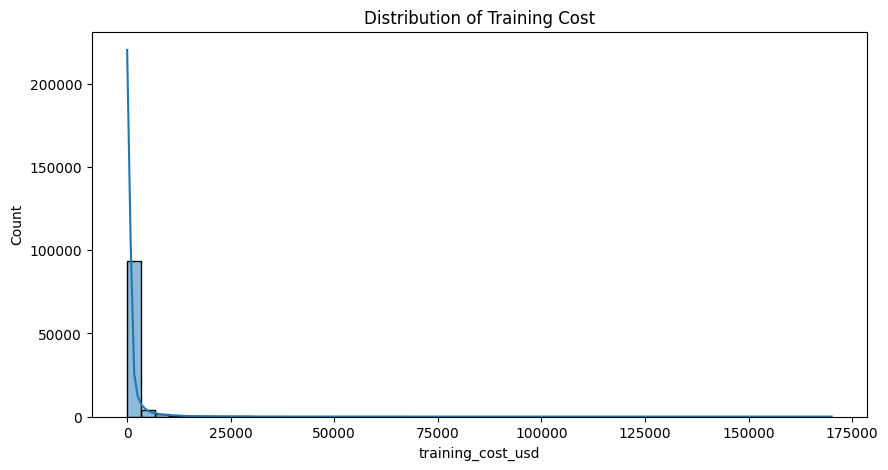

In [ ]:
# Target Variable Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df["training_cost_usd"],
    bins=50,
    kde=True
)

plt.title("Distribution of Training Cost")
plt.show()

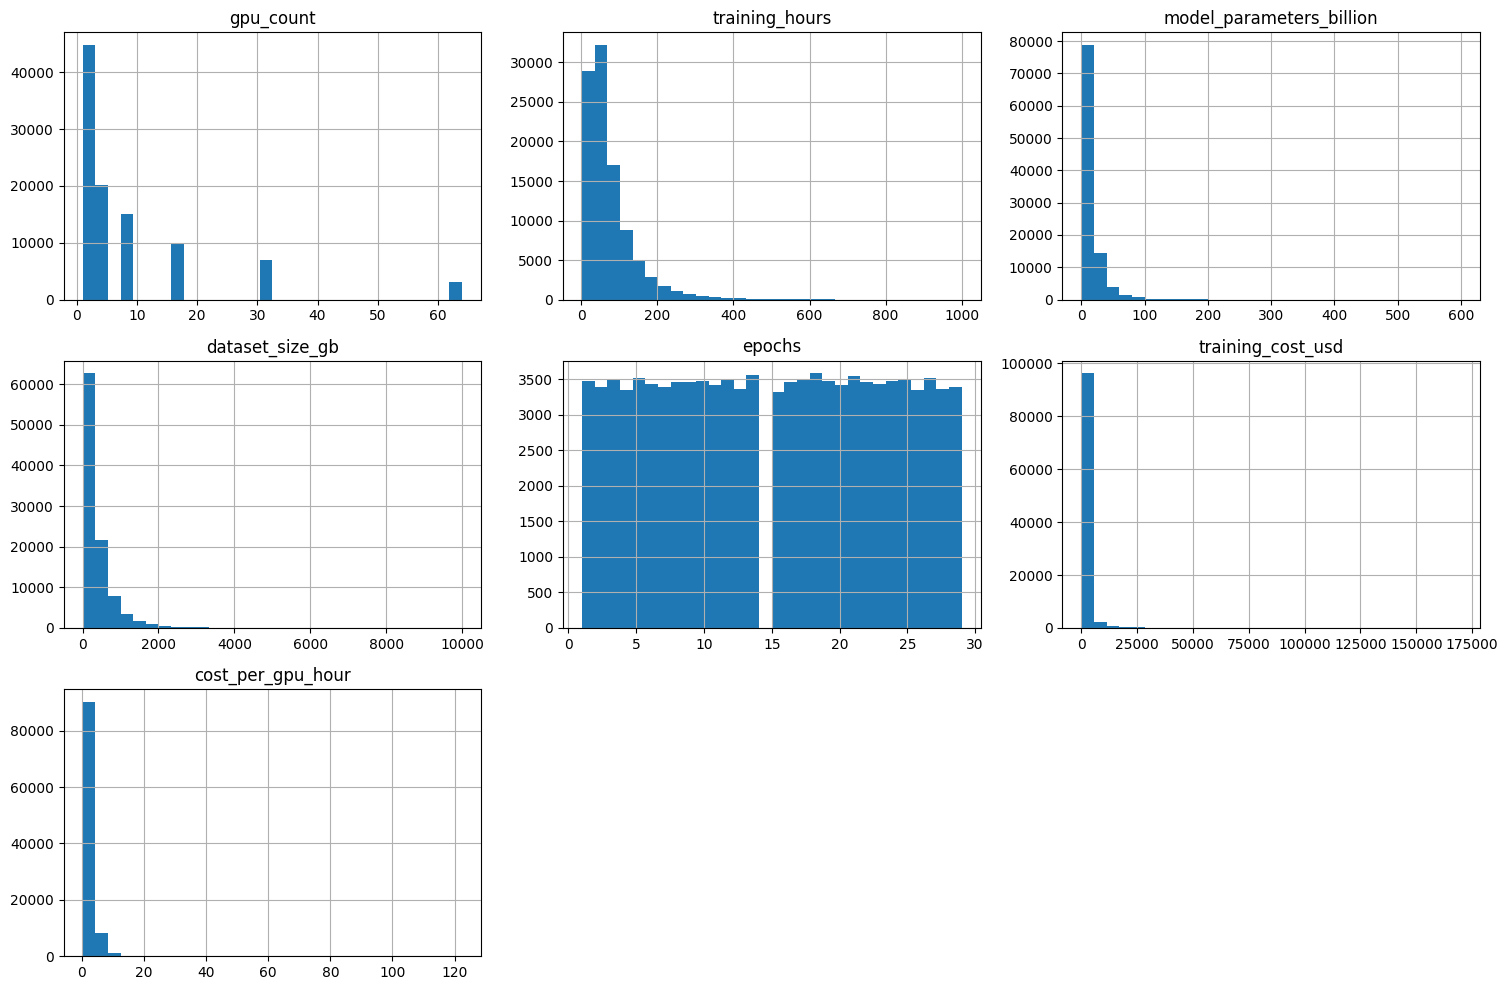

In [ ]:
df.hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation Analysis
eda_df = df.copy()

eda_df["cloud_provider"] = eda_df["cloud_provider"].astype("category").cat.codes

eda_df["gpu_type"] = eda_df["gpu_type"].astype("category").cat.codes

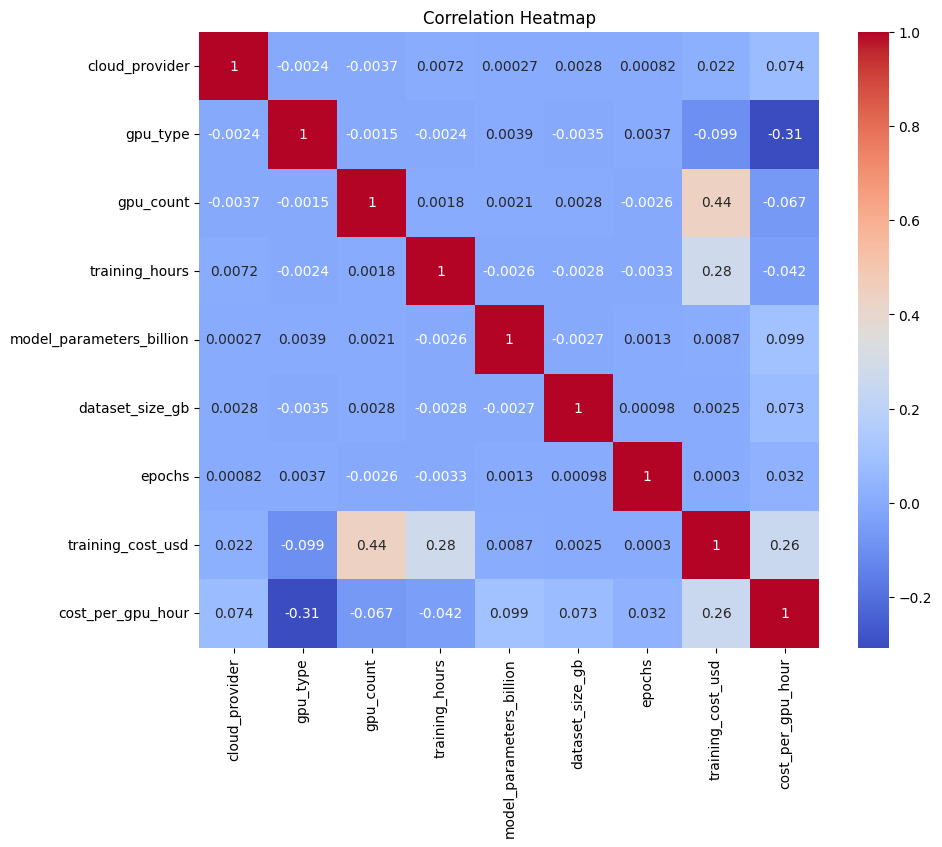

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Separate Features and Target

In [ ]:
X = df.drop(
    ["training_cost_usd", "cost_per_gpu_hour"],
    axis=1
)

y = df["training_cost_usd"]

print(X.shape)
print(y.shape)

(100000, 7)
(100000,)


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80000, 7)
(20000, 7)


# Handle Categorical Features
We have:

cloud_provider,
gpu_type

these are strings, so we will use One Hot Encoding for them.

In [ ]:
X_train = pd.get_dummies(
    X_train,
    columns=["cloud_provider", "gpu_type"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["cloud_provider", "gpu_type"],
    drop_first=True
)

In [ ]:
!pip install xgboost -q
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2  :", xgb_r2)

XGBoost
MAE : 219.04486510455226
RMSE: 940.1966635312962
R2  : 0.9271622163823894


In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
importance_df.head(10)

,Feature,Importance
8,gpu_type_H100,0.329131
7,gpu_type_A10G,0.199875
1,training_hours,0.166852
0,gpu_count,0.130138
9,gpu_type_T4,0.114658
6,cloud_provider_GCP,0.028129
3,dataset_size_gb,0.010517
4,epochs,0.007511
2,model_parameters_billion,0.007442
5,cloud_provider_Azure,0.005749


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

CV Scores: [0.91351097 0.92070124 0.89597142 0.9119278  0.92736741]
Average CV R2: 0.913895767991417


In [133]:
# Save model
import pickle

pickle.dump(
    xgb,
    open("trainwise_model.pkl", "wb")
)

pickle.dump(
    X_train.columns.tolist(),
    open("feature_columns.pkl", "wb")
)